# 6CS012 - Worksheet 5
## End-to-End CNN Model for Fruit Image Classification (Amazon Fruits Dataset)
---

## Imports & Setup

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
from sklearn.metrics import classification_report

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## Dataset Paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Update these paths to match your local directory structure
BASE_DIR  = 'FruitinAmazon'   # top-level folder from the zip
TRAIN_DIR = os.path.join(BASE_DIR, '/content/drive/MyDrive/AI AND ML/Data/FruitinAmazon/train')
TEST_DIR  = os.path.join(BASE_DIR, '/content/drive/MyDrive/AI AND ML/Data/FruitinAmazon/test')

print('Train directory:', TRAIN_DIR)
print('Test  directory:', TEST_DIR)
print('Classes found  :', os.listdir(TRAIN_DIR))

Train directory: /content/drive/MyDrive/AI AND ML/Data/FruitinAmazon/train
Test  directory: /content/drive/MyDrive/AI AND ML/Data/FruitinAmazon/test
Classes found  : ['acai', 'pupunha', 'graviola', 'tucuma', 'cupuacu', 'guarana']


---
# Task 1 — Data Understanding and Visualisation

## 1a. Visualise one random image per class in a 2-row grid

Number of classes: 6  →  ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


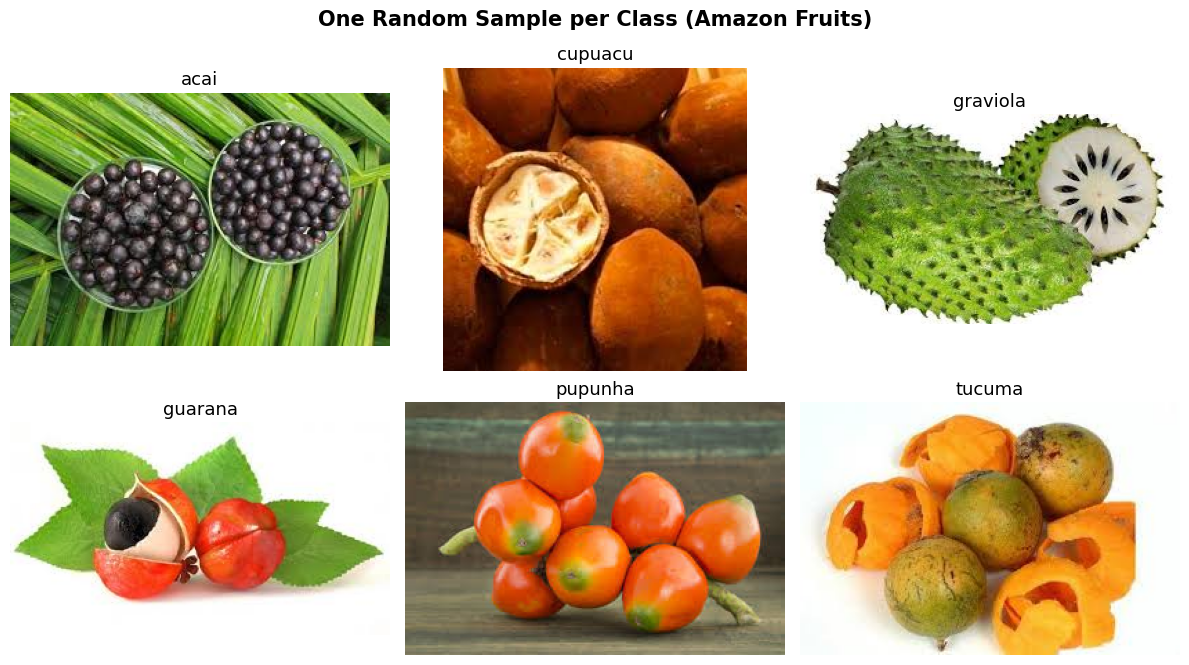


Observation:
  • The dataset contains 6 fruit classes: acai, cupuacu, graviola, guarana, pupunha, tucuma.
  • Images vary in size, background colour, and lighting conditions.
  • Some images contain multiple fruits; others show a single specimen.
  • The variation in appearance means the CNN must learn robust, class-specific features.



In [7]:
# -----------------------------------------------------------
# Get list of class directories from the train folder
# -----------------------------------------------------------
class_dirs = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
num_classes = len(class_dirs)
print(f'Number of classes: {num_classes}  →  {class_dirs}')

# -----------------------------------------------------------
# Select one random image from each class
# -----------------------------------------------------------
sampled = {}          # {class_name: image_path}
for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sampled[cls] = os.path.join(cls_path, random.choice(images))

# -----------------------------------------------------------
# Display images in a 2-row grid
# -----------------------------------------------------------
cols = 3                          # 3 images per row  → 2 rows for 6 classes
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 7))
axes = axes.flatten()

for idx, (cls_name, img_path) in enumerate(sampled.items()):
    img = Image.open(img_path).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(cls_name, fontsize=13)
    axes[idx].axis('off')

# Hide any unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('One Random Sample per Class (Amazon Fruits)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Observation
# -----------------------------------------------------------
print("""
Observation:
  • The dataset contains 6 fruit classes: acai, cupuacu, graviola, guarana, pupunha, tucuma.
  • Images vary in size, background colour, and lighting conditions.
  • Some images contain multiple fruits; others show a single specimen.
  • The variation in appearance means the CNN must learn robust, class-specific features.
""")

## 1b. Check for Corrupted Images

In [8]:
# -----------------------------------------------------------
# Iterate through every image in the train directory.
# Try to open each one; if it raises IOError or SyntaxError
# it is corrupted → remove it and log the path.
# -----------------------------------------------------------
corrupted_images = []

for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        image_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(image_path)
            img.verify()          # verifies integrity without loading fully
        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f'Removed corrupted image: {image_path}')

if not corrupted_images:
    print('No Corrupted Images Found.')
else:
    print(f'\nTotal corrupted images removed: {len(corrupted_images)}')

No Corrupted Images Found.


---
# Task 2 — Loading and Preprocessing Image Data

In [11]:
# -----------------------------------------------------------
# Training dataset
# -----------------------------------------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (IMG_HEIGHT, IMG_WIDTH),
    interpolation    = 'nearest',
    batch_size       = BATCH_SIZE,
    shuffle          = True,
    validation_split = VALIDATION_SPLIT,
    subset           = 'training',
    seed             = SEED
)

#  get class names BEFORE map
class_names = train_ds.class_names
print('Class names:', class_names)
print('Number of classes:', len(class_names))

# Apply normalisation
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


---
# Task 3 — Build the CNN Model

Architecture specified in the worksheet:

| Block | Layer | Details |
|---|---|---|
| Conv Block 1 | Conv2D | 32 filters, 3×3, padding=same, stride=1, ReLU |
| | MaxPooling2D | 2×2, stride=2 |
| Conv Block 2 | Conv2D | 32 filters, 3×3, padding=same, stride=1, ReLU |
| | MaxPooling2D | 2×2, stride=2 |
| FCN | Flatten | — |
| | Dense | 128 neurons, ReLU |
| | Dense | 64 neurons, ReLU |
| | Output Dense | num_classes neurons, Softmax |

In [12]:
num_classes = len(class_names)

model = keras.Sequential([
    # ── Input ──────────────────────────────────────────────
    layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # ── Convolutional Block 1 ──────────────────────────────
    layers.Conv2D(filters=32, kernel_size=(3, 3),
                  strides=(1, 1), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # ── Convolutional Block 2 ──────────────────────────────
    layers.Conv2D(filters=32, kernel_size=(3, 3),
                  strides=(1, 1), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # ── Fully Connected Network ────────────────────────────
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),

    # ── Output Layer ──────────────────────────────────────
    layers.Dense(num_classes, activation='softmax')
], name='CNN_FruitClassifier')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "CNN_FruitClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
# Task 4a — Compile the Model

In [13]:
model.compile(
    optimizer = 'adam',                          # adaptive learning rate optimiser
    loss      = 'sparse_categorical_crossentropy',  # integer labels
    metrics   = ['accuracy']
)

print('Model compiled successfully.')

Model compiled successfully.


---
# Task 4b — Train the Model

In [14]:
EPOCHS     = 250
BATCH_SIZE = 16    # as specified in the worksheet

# -----------------------------------------------------------
# Callbacks
# -----------------------------------------------------------

# 1. ModelCheckpoint – save the best model (lowest val_loss)
checkpoint_cb = ModelCheckpoint(
    filepath        = 'best_fruit_model.h5',
    monitor         = 'val_loss',
    save_best_only  = True,
    verbose         = 1
)

# 2. EarlyStopping – stop when val_loss stops improving
earlystop_cb = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,         # wait 20 epochs before stopping
    restore_best_weights = True,       # roll back to best weights
    verbose              = 1
)

# -----------------------------------------------------------
# Train
# -----------------------------------------------------------
history = model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = [checkpoint_cb, earlystop_cb]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.1759 - loss: 1.9688
Epoch 1: val_loss improved from None to 2.72237, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 870ms/step - accuracy: 0.1528 - loss: 2.0668 - val_accuracy: 0.0000e+00 - val_loss: 2.7224
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.2297 - loss: 1.7829
Epoch 2: val_loss improved from 2.72237 to 1.14781, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 879ms/step - accuracy: 0.2361 - loss: 1.7674 - val_accuracy: 0.8333 - val_loss: 1.1478
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.4248 - loss: 1.6287
Epoch 3: val_loss did not improve from 1.14781
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 0.4306 - loss: 1.6002 - val_accuracy: 0.1667 - val_loss: 1.5672
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.4583 - loss: 1.3626
Epoch 4: val_loss did not improve from 1.14781
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 443ms/step - accuracy: 0.5000 - loss: 1.3157 - val_accuracy: 0.2778 - val_loss: 1.5456
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.5804 - loss: 1.0769
Epoch 5: val_loss improved from 1.14781 to 0.92016, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 503ms/step - accuracy: 0.5694 - loss: 1.0934 - val_accuracy: 0.6667 - val_loss: 0.9202
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.7656 - loss: 0.8560
Epoch 6: val_loss did not improve from 0.92016
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 0.7500 - loss: 0.8538 - val_accuracy: 0.7778 - val_loss: 0.9713
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.7604 - loss: 0.6407
Epoch 7: val_loss improved from 0.92016 to 0.78727, saving model to best_fruit_model.h5



Epoch 7: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 521ms/step - accuracy: 0.7500 - loss: 0.6189 - val_accuracy: 0.7222 - val_loss: 0.7873
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.8050 - loss: 0.5567
Epoch 8: val_loss improved from 0.78727 to 0.53218, saving model to best_fruit_model.h5



Epoch 8: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 813ms/step - accuracy: 0.8056 - loss: 0.5534 - val_accuracy: 0.8333 - val_loss: 0.5322
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.9902 - loss: 0.2610
Epoch 9: val_loss did not improve from 0.53218
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 653ms/step - accuracy: 0.9861 - loss: 0.2717 - val_accuracy: 0.8889 - val_loss: 0.5467
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9699 - loss: 0.2371
Epoch 10: val_loss improved from 0.53218 to 0.29680, saving model to best_fruit_model.h5



Epoch 10: finished saving model to best_fruit_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 507ms/step - accuracy: 0.9722 - loss: 0.2305 - val_accuracy: 0.8889 - val_loss: 0.2968
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 1.0000 - loss: 0.1089
Epoch 11: val_loss did not improve from 0.29680
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 459ms/step - accuracy: 1.0000 - loss: 0.1164 - val_accuracy: 0.8889 - val_loss: 0.3237
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 1.0000 - loss: 0.0961
Epoch 12: val_loss did not improve from 0.29680
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 471ms/step - accuracy: 1.0000 - loss: 0.0947 - val_accuracy: 0.8889 - val_loss: 0.4362
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 1.0000 - loss: 0.0689
Epoch 13: val_loss did not improve from 0.29680
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 1.0000 - loss: 0.0543 - val_accuracy: 0.8889 - val_loss: 0.4088
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 1.0000 - loss: 0.0

### Visualise Training History (Loss & Accuracy)

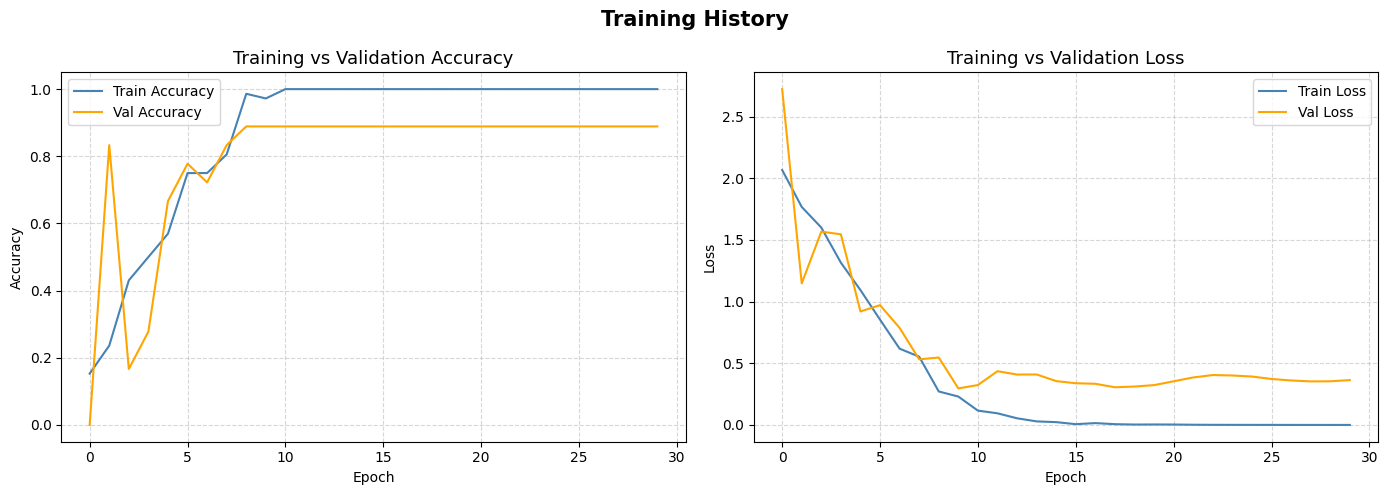

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ────────────────────────────────────────────────
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Training vs Validation Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# ── Loss ────────────────────────────────────────────────────
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Training vs Validation Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Task 5 — Evaluate the Model on the Test Set

In [16]:
# Evaluate on the held-out test set
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f'\n Test Loss    : {test_loss:.4f}')
print(f' Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f} %)')

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6333 - loss: 0.7858

 Test Loss    : 0.7858
 Test Accuracy: 0.6333  (63.33 %)


---
# Task 6 — Save and Load the Model

In [17]:
# -----------------------------------------------------------
# Save the trained model to an .h5 file
# -----------------------------------------------------------
SAVE_PATH = 'fruit_classifier_final.h5'
model.save(SAVE_PATH)
print(f'Model saved to: {SAVE_PATH}')

# -----------------------------------------------------------
# Load the saved model
# -----------------------------------------------------------
loaded_model = keras.models.load_model(SAVE_PATH)
print('Model loaded successfully.')

# -----------------------------------------------------------
# Re-evaluate the loaded model on the test set
# -----------------------------------------------------------
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f'\n [Loaded Model] Test Loss    : {loaded_loss:.4f}')
print(f' [Loaded Model] Test Accuracy: {loaded_acc:.4f}  ({loaded_acc*100:.2f} %)')

Model saved to: fruit_classifier_final.h5


Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6333 - loss: 0.7858

 [Loaded Model] Test Loss    : 0.7858
 [Loaded Model] Test Accuracy: 0.6333  (63.33 %)


---
# Task 7 — Predictions & Classification Report

In [18]:

# Step 1: Gather true labels from the test dataset

y_true = []
for _, labels_batch in test_ds:
    y_true.extend(labels_batch.numpy())
y_true = np.array(y_true)

# Step 2: Make predictions using model.predict()

predictions = loaded_model.predict(test_ds, verbose=1)

# Step 3: Convert probabilities → integer class labels
#         using np.argmax()
y_pred = np.argmax(predictions, axis=1)

print('\nSample predictions (first 10 images):')
print('Predicted:', [class_names[p] for p in y_pred[:10]])
print('Actual   :', [class_names[t] for t in y_true[:10]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step

Sample predictions (first 10 images):
Predicted: ['acai', 'cupuacu', 'acai', 'acai', 'acai', 'cupuacu', 'graviola', 'cupuacu', 'cupuacu', 'cupuacu']
Actual   : ['acai', 'acai', 'acai', 'acai', 'acai', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu', 'cupuacu']


In [19]:

# Step 4: Classification Report

from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names)
print('\nClassification Report:')
print('=' * 60)
print(report)


Classification Report:
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.57      0.80      0.67         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.25      0.40      0.31         5

    accuracy                           0.63        30
   macro avg       0.58      0.63      0.60        30
weighted avg       0.58      0.63      0.60        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step


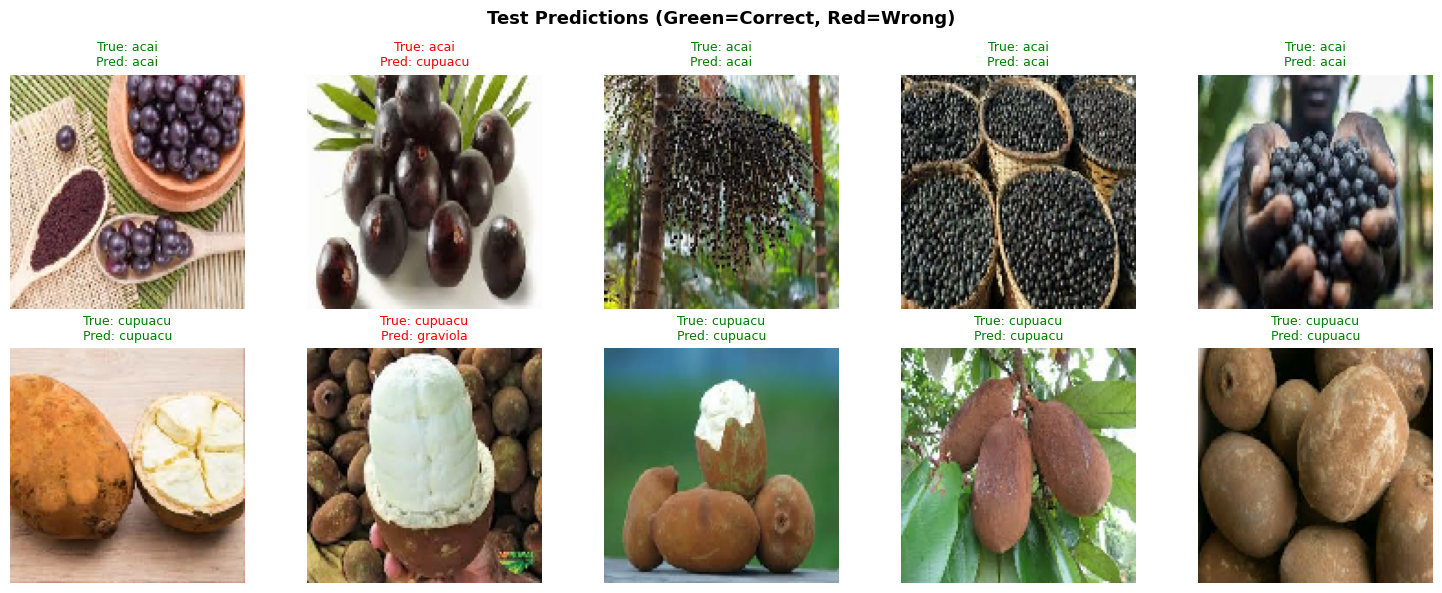

In [20]:

# Bonus: Visualise some test predictions

test_images_list = []
test_labels_list = []

for img_batch, lbl_batch in test_ds.take(1):
    test_images_list = img_batch.numpy()
    test_labels_list = lbl_batch.numpy()

preds_batch = loaded_model.predict(test_ds.take(1))
pred_labels = np.argmax(preds_batch, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(min(10, len(test_images_list))):
    axes[i].imshow(test_images_list[i])
    true_cls = class_names[test_labels_list[i]]
    pred_cls = class_names[pred_labels[i]]
    color    = 'green' if true_cls == pred_cls else 'red'
    axes[i].set_title(f'True: {true_cls}\nPred: {pred_cls}', color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()